## Analyzing trade dependence of countries and its relation to thier to economic stability. 
#### Does trade dependence affect economic stability?
* GDP Growth Volatility
    * Economic Instability = Standard deviation of GDP Growth over time
* Inflation Volatility
    * Unstable economies often have volatile inflation

#### How has trade openness evolved over the past 50 years?
* Trend analysis


#### How do democratic indicators relate to economic stability?

**Datasets**
1. GDP Growth (%Annual)
2. Inflation, consumer price (%Annual)
3. Imports of goods and services (%GDP)
4. Exports of goods and services (%GDP)
5. Merchandise trade (%GDP)

In [2]:
# Importing relevant libraries
import pandas as pd
import pycountry

In [3]:
# Function to clean data
def data_cleaner(raw_data):
    """
    Takes the raw data frame and processes it
    """
    raw_data = raw_data.drop(
        columns=["Indicator Name", "Indicator Code", "Unnamed: 69"])

    # removing aggregates
    iso_codes = [country.alpha_3 for country in pycountry.countries]
    clean_data = raw_data[raw_data["Country Code"].isin(iso_codes)]

    # deleting unwanted columns, ie 1960 to 80
    years_to_remove = [str(year) for year in range(1960, 1980)]
    clean_data = clean_data.drop(columns=years_to_remove)

    # dropping countries whose data is missing in 2000 (mention in methodology)
    clean_data = clean_data.dropna(subset=["2000"])
    # reseting index
    clean_data = clean_data.reset_index(drop=True)

    return clean_data


# Function to convert wide format data into a long format one

def data_metler(wide_data, data_subject):
    # melting the data from wide format to long format
    long_data = wide_data.melt(
        id_vars=["Country Name", "Country Code"],
        var_name="Year",
        value_name=data_subject
    )
    return long_data



# Cleaning EIU Democracy data
def new_data_cleaner(raw_data):
    raw_data = raw_data.drop(
        columns = ['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'INDICATOR', 'SEX', 'AGE', 'URBANISATION', 'UNIT_MEASURE', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3', 'TIME_FORMAT', 'UNIT_MULT', 'DATA_SOURCE', 'OBS_CONF', 'FREQ_LABEL', 'INDICATOR_LABEL', 'SEX_LABEL', 'AGE_LABEL', 'URBANISATION_LABEL', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2_LABEL', 'UNIT_TYPE_LABEL', 'DATABASE_ID_LABEL', 'TIME_FORMAT_LABEL', 'UNIT_MULT_LABEL', 'OBS_CONF_LABEL' , 'DATABASE_ID', 'UNIT_TYPE', 'COMP_BREAKDOWN_3_LABEL']
    )

    iso_codes = [country.alpha_3 for country in pycountry.countries]
    clean_data = raw_data[raw_data["REF_AREA"].isin(iso_codes)]
    clean_data = clean_data.reset_index(drop = True)
    
    return clean_data


In [ ]:
# Loading data and cleaning data

# GDP Growth Annual
gdp_data_path = "~/Development/ds-env/vscode/global-trade-analytics-project/data/raw/gdp-growth-annual/API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_40824.csv"
gdp_data = pd.read_csv(gdp_data_path, skiprows=4)

# Inflation, cpi Annual
inflation_data_path = "~/Development/ds-env/vscode/global-trade-analytics-project/data/raw/inflation_consumerprices_annual/API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_32.csv"
inflation_data = pd.read_csv(inflation_data_path, skiprows=4)

# imports %GDP
imports_data_path = "~/Development/ds-env/vscode/global-trade-analytics-project/data/raw/imports-of-goods-and-services/API_NE.IMP.GNFS.ZS_DS2_en_csv_v2_133.csv"
imports_data = pd.read_csv(imports_data_path, skiprows=4)

# exports %GDP
exports_data_path = "~/Development/ds-env/vscode/global-trade-analytics-project/data/raw/exports-of-goods-and-services/API_NE.EXP.GNFS.ZS_DS2_en_csv_v2_1866.csv"
exports_data = pd.read_csv(exports_data_path, skiprows=4)

# merchandise trade %GDP
merchandise_trade_data_path = "/home/marvin/Development/ds-env/vscode/global-trade-analytics-project/data/raw/merchandise-trade-wbg/API_TG.VAL.TOTL.GD.ZS_DS2_en_csv_v2_4589.csv"
merchandise_trade_data = pd.read_csv(merchandise_trade_data_path, skiprows=4)


# Data Cleaning
gdp_data = data_cleaner(gdp_data)
inflation_data = data_cleaner(inflation_data)
imports_data = data_cleaner(imports_data)
exports_data = data_cleaner(exports_data)
merchandise_trade_data = data_cleaner(merchandise_trade_data)

#Data melting
gdp_data = data_metler(gdp_data, "GDP Growth")
inflation_data = data_metler(inflation_data, "Inflation annual")
imports_data = data_metler(imports_data, "Imports per GDP")
exports_data = data_metler(exports_data, "Exports per GDP")
merchandise_trade_data = data_metler(merchandise_trade_data, "Merchadise Trade per GDP")


NameError: name 'democracy_index_data' is not defined

In [ ]:
# Merging datasets into one panel dataset with an outer merge, i.e., a union dataset

panel_df = gdp_data.merge(inflation_data, on=["Country Name", "Country Code", "Year"], 
                          how="outer")

panel_df = panel_df.merge(imports_data, on=["Country Name", "Country Code", "Year"], 
                          how="outer")

panel_df = panel_df.merge(exports_data, on=["Country Name", "Country Code", "Year"], 
                          how="outer")

panel_df = panel_df.merge(merchandise_trade_data, on=["Country Name", "Country Code", "Year"], 
                          how="outer")

panel_df.head()


#casting year as int and sorting
panel_df["Year"] = panel_df["Year"].astype(int)
panel_df = panel_df.sort_values(["Country Code", "Year"])



# Trade Dependence Index - 
The trade dependence index or the openness index is a simplistic measure of the relevance of international trade in an economy. It provides an indication of the degree to which an economy is open to trade, or dependant on trade. 

**Definition**: The value of total trade (imports plus exports) as percentages of GDP, i.e., Trade dependence Index = Imports (%GDP) + Exports (%GDP)

In [ ]:
#Creating trade dependence/openness variable
panel_df["Trade Dependence"] = (
    panel_df["Imports per GDP"] + panel_df["Exports per GDP"]
)

panel_df

In [ ]:
#Economic Instability = volatility of GDP Growth 

panel_df["GDP Volatility (5y)"] = (
    panel_df
    .groupby("Country Code")["GDP Growth"]
    .rolling(window = 5)
    .std()
    .reset_index(level=0, drop = True)
)

panel_df

<Axes: xlabel='Year'>

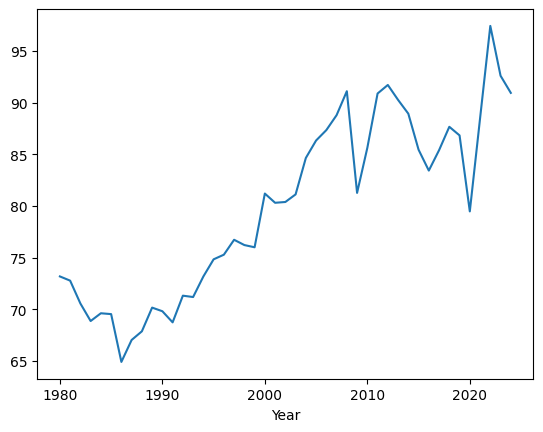

In [ ]:
# How has trade openness evolved?

trade_trend = (
    panel_df
    .groupby("Year")["Trade Dependence"]
    .mean()
)

trade_trend.plot()

<Axes: xlabel='Trade Dependence', ylabel='GDP Volatility (5y)'>

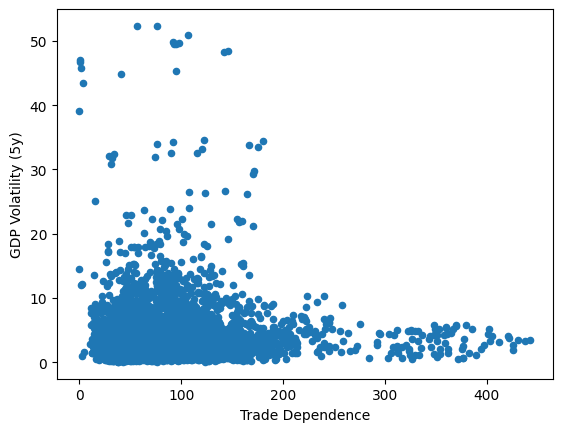

In [101]:
# Does trade openness correlate with volatility?

panel_df.plot.scatter(
    x = "Trade Dependence",
    y = "GDP Volatility (5y)"
)

,Country Name,Country Code,Year,GDP Growth,Inflation annual,Imports per GDP,Exports per GDP,Merchadise Trade per GDP,Trade Dependence,GDP Volatility (5y),Inflation Volatility (5y)
360,Aruba,ABW,1980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
361,Aruba,ABW,1981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
362,Aruba,ABW,1982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,Aruba,ABW,1983,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,Aruba,ABW,1984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
9085,Zimbabwe,ZWE,2020,-7.816951,NaN,21.247181,18.931225,31.388039,40.178406,6.054469,NaN
9086,Zimbabwe,ZWE,2021,8.468017,NaN,24.354942,19.759617,32.971100,44.114559,7.367571,NaN
9087,Zimbabwe,ZWE,2022,6.139263,NaN,31.368133,23.699220,37.389381,55.067352,7.578299,NaN
9088,Zimbabwe,ZWE,2023,5.350869,NaN,23.174185,17.117076,45.827110,40.291261,7.623746,NaN


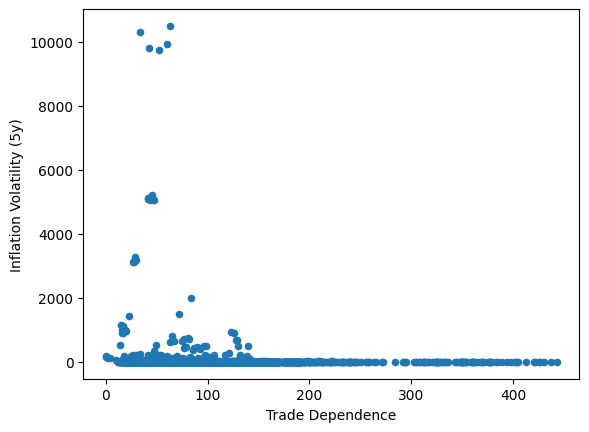

In [ ]:
# Inflation volatility - unstable economies have volatile inflation

panel_df["Inflation Volatility (5y)"] = (
    panel_df.groupby("Country Code")["Inflation annual"]
    .rolling(window = 5)
    .std()
    .reset_index(level= 0, drop=True)
        
)

panel_df.plot.scatter(
    x = "Trade Dependence",
    y = "Inflation Volatility (5y)"
)

panel_df




In [ ]:
# analysis_df = panel_df.dropna(
#     subset=["Trade Dependence", "GDP Volatility (5y)"]
# )


# import statsmodels.api as sm

# X = analysis_df["Trade Dependence"]
# X = sm.add_constant(X)

# y = analysis_df["GDP Volatility (5y)"]

# model = sm.OLS(y, X).fit()
# print(model.summary())


                             OLS Regression Results                            
Dep. Variable:     GDP Volatility (5y)   R-squared:                       0.003
Model:                             OLS   Adj. R-squared:                  0.002
Method:                  Least Squares   F-statistic:                     15.30
Date:                 Mon, 16 Feb 2026   Prob (F-statistic):           9.27e-05
Time:                         12:39:44   Log-Likelihood:                -17221.
No. Observations:                 6091   AIC:                         3.445e+04
Df Residuals:                     6089   BIC:                         3.446e+04
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                3.3455   

In [5]:
# Democracy index data loading

democracy_index_data_path = "/home/marvin/Development/ds-env/vscode/global-trade-analytics-project/data/raw/EIU_DI.csv"
democracy_index_data = pd.read_csv(democracy_index_data_path)
democracy_index_data.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,URBANISATION_LABEL,UNIT_MEASURE_LABEL,COMP_BREAKDOWN_1_LABEL,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,UNIT_TYPE_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,AFG,EIU_DI_INDEX,_Z,_Z,_Z,0_TO_10,...,Not applicable,0-10 scale,Total,Not Applicable,Not Applicable,Index,Democracy Index,CCYY,Units,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,AFG,EIU_DI_INDEX,_Z,_Z,_Z,0_TO_10,...,Not applicable,0-10 scale,Total,Not Applicable,Not Applicable,Index,Democracy Index,CCYY,Units,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,AFG,EIU_DI_INDEX,_Z,_Z,_Z,0_TO_10,...,Not applicable,0-10 scale,Total,Not Applicable,Not Applicable,Index,Democracy Index,CCYY,Units,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,AFG,EIU_DI_INDEX,_Z,_Z,_Z,0_TO_10,...,Not applicable,0-10 scale,Total,Not Applicable,Not Applicable,Index,Democracy Index,CCYY,Units,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,AFG,EIU_DI_INDEX,_Z,_Z,_Z,0_TO_10,...,Not applicable,0-10 scale,Total,Not Applicable,Not Applicable,Index,Democracy Index,CCYY,Units,Public


In [ ]:

# Democracy index data cleaning
democracy_index_data = new_data_cleaner(democracy_index_data)
# Rename 'OLD_NAME' to 'NEW_NAME'
democracy_index_data = democracy_index_data.rename(columns={'REF_AREA': 'Country Code', 'TIME_PERIOD': 'Year', 'OBS_VALUE': 'Democracy Index', 'REF_AREA_LABEL': 'Country Name'})

democracy_index_data = democracy_index_data[['Country Name', 'Country Code', 'Year', 'Democracy Index']]

panel_df = panel_df.merge(democracy_index_data, on=["Country Name", "Country Code", "Year"], 
                          how="outer")




#casting year as int and sorting
panel_df["Year"] = panel_df["Year"].astype(int)
panel_df = panel_df.sort_values(["Country Code", "Year"])


panel_df.head()



panel_df.plot.scatter(
    x = "Democracy Index",
    y = "GDP Volatility (5y)"
    
)





In [141]:
panel_df["Democracy Index"].corr(panel_df["GDP Volatility (5y)"])

np.float64(-0.10512573373938384)

<Axes: xlabel='Democracy Index', ylabel='GDP Volatility (5y)'>

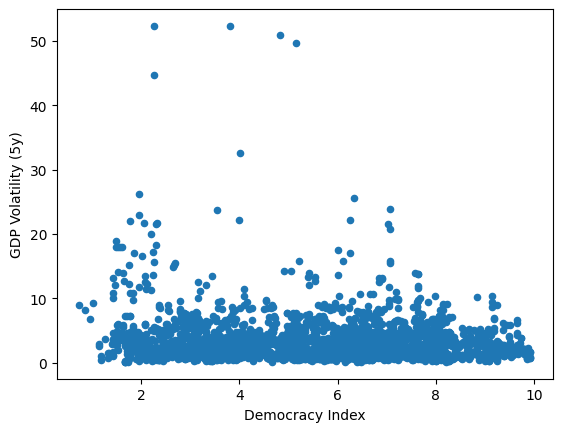

In [144]:
panel_df.plot.scatter(
    x = "Democracy Index",
    y = "GDP Volatility (5y)"
    
)

In [ ]:
sns.regplot(
    data= panel_dataframe,
    x="Trade Dependence",
    y="GDP Volatility (5y)",
    scatter_kws ={"alpha":0.3}
)
plt.title("Trade Dependence vs GDP Volatility")

**Trade Dependence and Volatility: Linear Fit -** Adding a regression line indicates a slight positive association between trade dependence and GDP volatility. However, the slope is shallow and the dispersion around the fitted line is substantial, suggesting limited explanatory power.

While the relationship appears directionally positive, the wide spread of observations implies that factors beyond trade dependence play a significant role in determining economic volatility.
